In [1]:
import os
import os, sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Sequential
import torch.optim as optim
import voxelmorph as vxm
import neurite as ne
os.environ['VXM_BACKEND'] = 'pytorch'

backend:pytorch
Pytorch


In [2]:
os.environ.get('VXM_BACKEND')

'pytorch'

In [3]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [4]:
x_train = np.load('Train_3D_128_FOV_norm_data.npz')['Train']
x_train = np.transpose(x_train, (3, 0, 1, 2))
vol_shape = x_train.shape[1:]
print('train vol_shape:', vol_shape)
print('train shape:', x_train.shape)

train vol_shape: (128, 128, 128)
train shape: (57, 128, 128, 128)


In [5]:
# configure unet input shape (concatenation of moving and fixed images)
ndim = 3
unet_input_features = 2
inshape = (*x_train.shape[1:], unet_input_features)

# configure unet features 
# nb_features = [
#     [16, 32, 32, 32],
#     [32, 32, 32, 32, 32, 16, 16]
# ]

nb_features = [
    [32, 64, 64, 64],
    [64, 64, 64, 64, 32, 16, 16]
]

# nb_features = [
#     [64, 128, 256, 512],
#     [512, 512, 256, 128, 64, 32, 16]
# ]
model3D = vxm.networks.VxmDense(vol_shape, nb_features, int_steps=0)
model3D.to(device)

5
6
7
6
7
6
7
6
7
8
9
10
8
9
10
8
9
10
8
9
10
11
11
11
5
6
7
6
7
6
7
6
7
8
9
10
8
9
10
8
9
10
8
9
10
11
11
11
5
6
7
6
7
6
7
6
7
8
9
10
8
9
10
8
9
10
8
9
10
11
11
11
5
6
7
6
7
6
7
6
7
8
9
10
8
9
10
8
9
10
8
9
10
11
11
11
[64, 64, 64]


C:\Users\user\anaconda3\envs\nn\lib\site-packages\torch\functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\TensorShape.cpp:3550.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


VxmDense(
  (unet_model_128_1): Unet(
    (encoder): ModuleList(
      (0): ModuleList(
        (0): ConvBlock(
          (main): Conv3d(2, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (activation): LeakyReLU(negative_slope=0.2)
        )
      )
      (1): ModuleList(
        (0): ConvBlock(
          (main): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (activation): LeakyReLU(negative_slope=0.2)
        )
      )
      (2-3): 2 x ModuleList(
        (0): ConvBlock(
          (main): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (activation): LeakyReLU(negative_slope=0.2)
        )
      )
    )
    (decoder): ModuleList(
      (0): ModuleList(
        (0): ConvBlock(
          (main): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (activation): LeakyReLU(negative_slope=0.2)
        )
      )
      (1-3): 3 x ModuleList(
        (0): ConvBlo

In [6]:
import torch

def vxm_data_generator(x_data, batch_size):
    vol_shape = x_data.shape[1:]  # データ形状を取得
    ndims = len(vol_shape)
    
    zero_phi = np.zeros([batch_size, *vol_shape, ndims])
    
    while True:
        idx1 = np.random.randint(0, x_data.shape[0], size=batch_size)
        moving_images = x_data[idx1, ..., np.newaxis]
        idx2 = np.random.randint(0, x_data.shape[0], size=batch_size)
        fixed_images = x_data[idx2, ..., np.newaxis]

        # TensorFlowからPyTorchのデータ形式に変換
        moving_images = torch.tensor(moving_images).permute(0, 4, 1, 2, 3).float()
        fixed_images = torch.tensor(fixed_images).permute(0, 4, 1, 2, 3).float()

        # チャンネルを最初の次元に追加
        moving_images = moving_images.permute(0, 1, 2, 3, 4)  # チャンネルを最初の次元に移動
        fixed_images = fixed_images.permute(0, 1, 2, 3, 4)  # チャンネルを最初の次元に移動

        inputs = [moving_images, fixed_images]
        outputs = [fixed_images, zero_phi]

        yield (inputs, outputs)

In [7]:
train_generator = vxm_data_generator(x_train, batch_size=2)
in_sample, out_sample = next(train_generator)

# in_sampleとout_sampleの内容を確認する
print("Input Sample Shapes:")
print("Moving Images Shape:", in_sample[0].shape)
print("Fixed Images Shape:", in_sample[1].shape)

print("\nOutput Sample Shapes:")
print("Moved Images (Fixed) Shape:", out_sample[0].shape)
print("Zero Gradient Shape:", out_sample[1].shape)

Input Sample Shapes:
Moving Images Shape: torch.Size([2, 1, 128, 128, 128])
Fixed Images Shape: torch.Size([2, 1, 128, 128, 128])

Output Sample Shapes:
Moved Images (Fixed) Shape: torch.Size([2, 1, 128, 128, 128])
Zero Gradient Shape: (2, 128, 128, 128, 3)


In [8]:
mse_loss = vxm.losses.MSE().loss
grad_loss = vxm.losses.Grad('l2').loss

def total_loss(y_true, y_pred):
    mse = mse_loss(y_true, y_pred)
    grad = grad_loss(y_true, y_pred)
    return mse + 0.01 * grad, mse, grad
#     return mse_loss(y_true, y_pred)

In [9]:
optimizer = optim.Adam(model3D.parameters(), lr=1e-4)

In [13]:
from tqdm.notebook import tqdm
# from visdom import Visdom

# viz = Visdom()

epochs = 1000
losses = []
losses_16 = []
losses_32 = []
losses_64 = []
losses_128 = []
mses = []
mses_16 = []
mses_32 = []
mses_64 = []
mses_128 = []
grads = []
grads_16 = []
grads_32 = []
grads_64 = []
grads_128 = []


# model3D.load_state_dict(torch.load('model_VXM_3D_weights_SGDm.pth', map_location=device)
for epoch in tqdm(range(epochs)):
    
    # 学習データのバッチを取得
    train_batch,_ = next(train_generator)
    moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
    fixed_images = torch.tensor(train_batch[1], dtype=torch.float32)            
    moving_images = moving_images.to(device)
    fixed_images = fixed_images.to(device)
    # 勾配を初期化
    optimizer.zero_grad()

    # 順伝播
#     transformed_image, _ = model3D(moving_images, fixed_images)
#     loss, mse, grad = total_loss(fixed_images, transformed_image)
    
#     source_16, target_16, moved_16_2, flow_field_16, source_32, moved_32, target_32, moved_32_2, flow_field_32, source_64  moved_64, target_64, moved_64_2, flow_field_64, source_128 moved_128, target_128, moved_128_2, pos_flow = model3D(moving_images, fixed_images)
#     source_16, target_16, moved_16_2, flow_field_16, source_32, moved_32, target_32, moved_32_2, flow_field_32, source_64, moved_64, target_64, moved_64_2, flow_field_64, source_128, moved_128, target_128, moved_128_2, pos_flow = model3D(moving_images, fixed_images)
#     source_64, target_64, moved_64_2, flow_field_64, source_128, moved_128, target_128, moved_128_2, pos_flow= model3D(moving_images, fixed_images)
#     source_16, target_16, moved_16_2, flow_field_16, source_32, moved_32, target_32, moved_32_2, flow_field_32, source_64,  \
#     moved_64, target_64, moved_64_2, flow_field_64, source_128, moved_128, target_128, moved_128_2, pos_flow, flow_field_all,\
#     moved_128_final = model3D(moving_images, fixed_images)

    source_16, target_16, source_16_128, target_16_128, source_32, target_32, source_32_128, target_32_128, \
    ource_64, target_64, source_64_128, target_64_128, \
    source_128, target_128, moved_16_2, moved_32_2, moved_64_2, moved_128_2= model3D(moving_images, fixed_images)
    
    loss_16, mse_16, grad_16 = total_loss(target_16_128, moved_16_2)
    loss_32, mse_32, grad_32 = total_loss(target_32_128, moved_32_2)  
    loss_64, mse_64, grad_64 = total_loss(target_64_128, moved_64_2)
    loss_128, mse_128, grad_128 = total_loss(target_128, moved_128_2)
    
    loss_all = loss_16 + loss_32 + loss_64 + loss_128
#     loss_all = loss_64 + loss_128


    # 逆伝播
    loss_all.backward()
    optimizer.step()

    torch.save(model3D.state_dict(), 'model_VXM_3D_weights_V2_omomi.pth')

#     pbar.update(1)
#     pbar.set_postfix({'Loss': loss.item()})
        
    # エポックごとのロスを保存

    
    losses_16.append(loss_16)
    mses_16.append(mse_16)
    grads_16.append(grad_16)
    
    losses_32.append(loss_32)
    mses_32.append(mse_32)
    grads_32.append(grad_32) 
    
    losses_64.append(loss_64)
    mses_64.append(mse_64)
    grads_64.append(grad_64)
    
    losses_128.append(loss_128)
    mses_128.append(mse_128)
    grads_128.append(grad_128)
    losses.append(loss_all)    
    
#     viz.line(X=np.array([epoch]), Y=np.array([losses]), win='loss', name='train_loss', update='append')

    # エポックごとのロスの表示
#     print(f"Epoch {epoch+1}/{epochs}, Loss: {loss_all:.4f}")
    print(f"Epoch {epoch+1}/{epochs}, Loss_16: {loss_16:.4f}, Loss_32: {loss_32:.4f}, Loss_64: {loss_64:.4f}, Loss_128: {loss_128:.4f}, Total Loss: {loss_all:.4f}")
#     print(f"Epoch {epoch+1}/{epochs}, Loss_64: {loss_64:.4f}, Loss_128: {loss_128:.4f}, Total Loss: {loss_all:.4f}")


  0%|          | 0/1000 [00:00<?, ?it/s]

C:\Users\user\AppData\Local\Temp\ipykernel_8940\2999933189.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
C:\Users\user\AppData\Local\Temp\ipykernel_8940\2999933189.py:30: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fixed_images = torch.tensor(train_batch[1], dtype=torch.float32)


aaaa tensor(0.0047, device='cuda:0', grad_fn=<MaxBackward1>)
Epoch 1/1000, Loss_16: 0.0202, Loss_32: 0.0237, Loss_64: 0.0264, Loss_128: 0.0317, Total Loss: 0.1021
aaaa tensor(0.0051, device='cuda:0', grad_fn=<MaxBackward1>)
Epoch 2/1000, Loss_16: 0.0156, Loss_32: 0.0185, Loss_64: 0.0207, Loss_128: 0.0255, Total Loss: 0.0802
aaaa tensor(0.0056, device='cuda:0', grad_fn=<MaxBackward1>)
Epoch 3/1000, Loss_16: 0.0228, Loss_32: 0.0263, Loss_64: 0.0289, Loss_128: 0.0338, Total Loss: 0.1119
aaaa tensor(0.0061, device='cuda:0', grad_fn=<MaxBackward1>)
Epoch 4/1000, Loss_16: 0.0178, Loss_32: 0.0205, Loss_64: 0.0231, Loss_128: 0.0282, Total Loss: 0.0896
aaaa tensor(0.0068, device='cuda:0', grad_fn=<MaxBackward1>)
Epoch 5/1000, Loss_16: 0.0162, Loss_32: 0.0177, Loss_64: 0.0194, Loss_128: 0.0236, Total Loss: 0.0768
aaaa tensor(0.0075, device='cuda:0', grad_fn=<MaxBackward1>)
Epoch 6/1000, Loss_16: 0.0217, Loss_32: 0.0232, Loss_64: 0.0252, Loss_128: 0.0297, Total Loss: 0.0996
aaaa tensor(0.0090, de

ValueError: x and y must have same first dimension, but have shapes (1,) and (1000,)

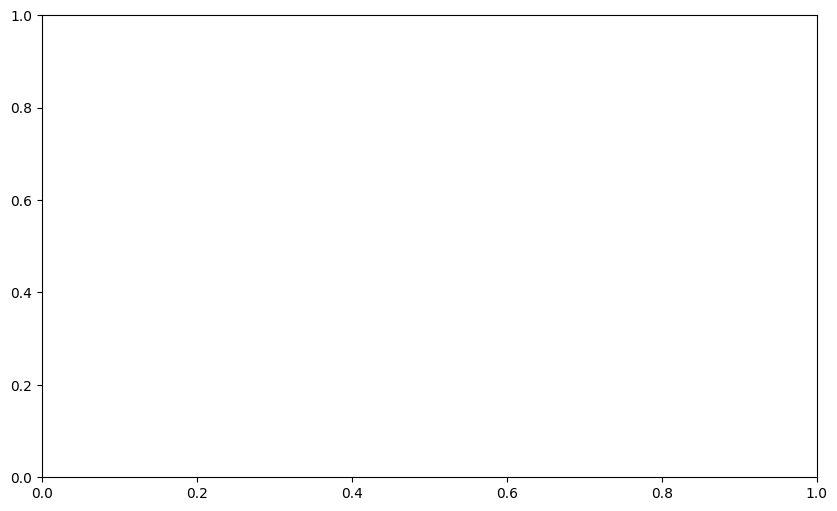

In [15]:
import numpy as np
import matplotlib.pyplot as plt
losses_np = [loss.item() for loss in losses]

plt.figure(figsize=(10, 6))
plt.plot(epochs, losses_np, label='Total Loss')
plt.plot(epochs, losses_16_np, label='Loss_16')
plt.plot(epochs, losses_32_np, label='Loss_32')
plt.plot(epochs, losses_64_np, label='Loss_64')
plt.plot(epochs, losses_128_np, label='Loss_128')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Losses')
plt.legend()
plt.show()

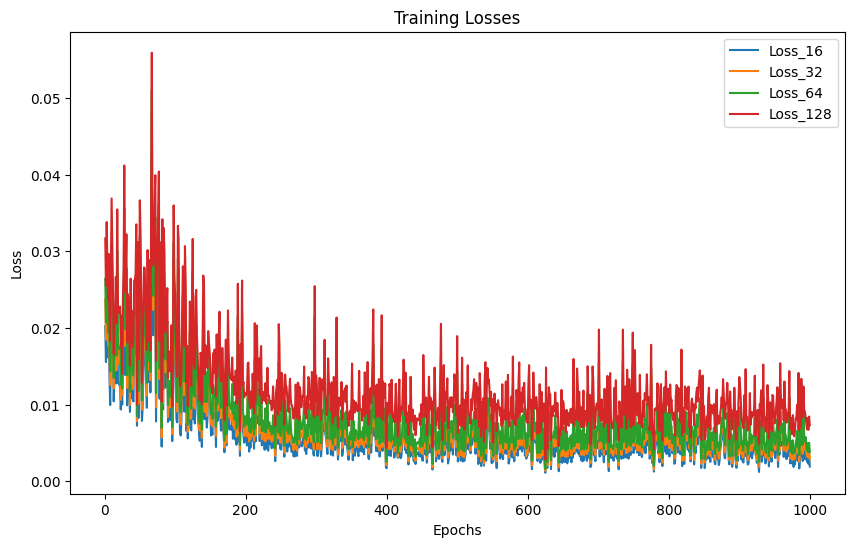

In [43]:
import numpy as np
import matplotlib.pyplot as plt

epochs = range(1, len(losses_16) + 1)

losses_16_np = [loss.item() for loss in losses_16]
losses_32_np = [loss.item() for loss in losses_32]
losses_64_np = [loss.item() for loss in losses_64]
losses_128_np = [loss.item() for loss in losses_128]

plt.figure(figsize=(10, 6))
plt.plot(epochs, losses_16_np, label='Loss_16')
plt.plot(epochs, losses_32_np, label='Loss_32')
plt.plot(epochs, losses_64_np, label='Loss_64')
plt.plot(epochs, losses_128_np, label='Loss_128')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Losses')
plt.legend()

# Save the plot to a file
plt.savefig('training_lossesV2.png')

# Show the plot
plt.show()


In [17]:
CT1 = np.load('No6_CT1.npz')['Val']
CT1 = np.transpose(CT1, (3, 0, 1, 2))
print('CT1_shape:', CT1.shape)
CT2 = np.load('No6_CT2.npz')['Val']
CT2 = np.transpose(CT2, (3, 0, 1, 2))
print('CT2_shape:', CT2.shape)

CT1_shape: (1, 128, 128, 128)
CT2_shape: (1, 128, 128, 128)


In [18]:
x_val_1 = CT1[0, :, :, :]
x_val_1 = x_val_1[np.newaxis, ..., np.newaxis]
x_val_2 = CT2[0, :, :, :]
x_val_2 = x_val_2[np.newaxis, ..., np.newaxis]

batch_size = 2

idx1 = np.random.randint(0, x_val_1.shape[0], size=batch_size)
moving_images = x_val_1[idx1]
moving_images = torch.tensor(moving_images).permute(0, 4, 1, 2, 3).float()
moving_images11 = moving_images.permute(0, 1, 2, 3, 4)
print(moving_images11.shape)

idx2 = np.random.randint(0, x_val_2.shape[0], size=batch_size)
fixed_images = x_val_2[idx2]
fixed_images = torch.tensor(fixed_images).permute(0, 4, 1, 2, 3).float()
fixed_images11 = fixed_images.permute(0, 1, 2, 3, 4)
print(fixed_images11.shape)

torch.Size([2, 1, 128, 128, 128])
torch.Size([2, 1, 128, 128, 128])


In [22]:
import numpy as np
import matplotlib.pyplot as plt

# 学習済みモデルが既にある場合
model3D.load_state_dict(torch.load('model_VXM_3D_weights_V2_omomi.pth', map_location=device))


# 検証データを使って予測を行う
model3D.eval()  # モデルを評価モードにする
with torch.no_grad():  # 勾配計算を無効化
#     moving_images = moving_images
#     fixed_images = fixed_images

    moving_images = fixed_images11
    fixed_images = moving_images11

#     train_batch,_ = next(train_generator)
#     moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
#     fixed_images = torch.tensor(train_batch[1], dtype=torch.float32)  
    
    moving_images = moving_images.to(device)
    fixed_images = fixed_images.to(device)
    # source_16, target_16, moved_16_2, flow_field_16, source_32, moved_32, target_32, moved_32_2, flow_field_32,\
    # source_64,  moved_64, target_64, moved_64_2, flow_field_64, source_128, moved_128, target_128, moved_128_2, \
    # pos_flow, flow_field_all, moved_128_final= model3D(moving_images, fixed_images)

    source_16, target_16, source_16_128, target_16_128, source_32, target_32, source_32_128, target_32_128, \
    ource_64, target_64, source_64_128, target_64_128, \
    source_128, target_128, moved_16_2, moved_32_2, moved_64_2, moved_128_2= model3D(moving_images, fixed_images)
    

aaaa tensor(65.6714, device='cuda:0')


NameError: name 'pos_flow' is not defined

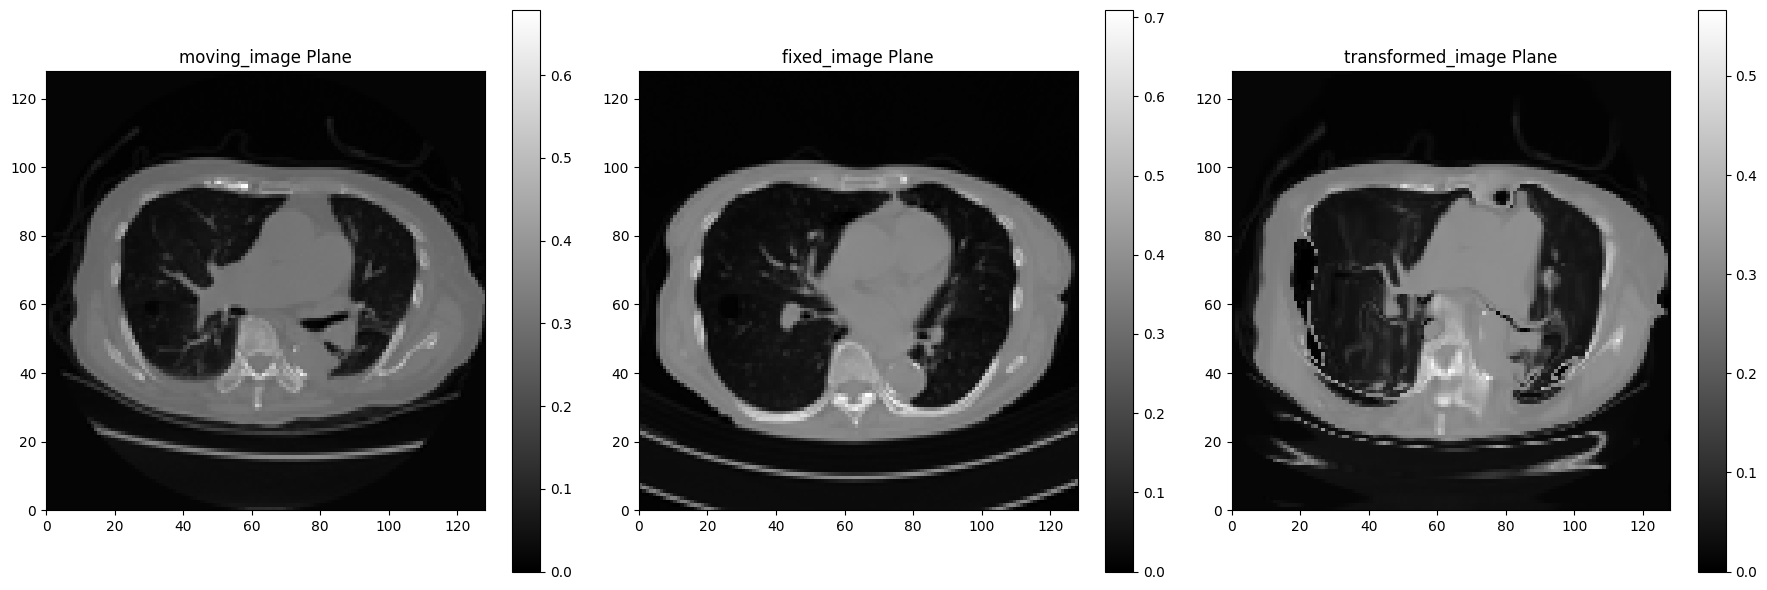

In [44]:
import numpy as np
import torch
from tifffile import imsave
plt.figure(figsize=(18, 6))  # 図のサイズを大きくする

moving_image = source_128[0].cpu().numpy()
fixed_image = target_128[0].cpu().numpy()
transformed_image = moved_128_2[0].cpu().numpy()

# moving_imageの表示32￥
plt.subplot(131)
A = moving_image[0, 64, :, :]
plt.imshow(A, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('moving_image Plane')
plt.colorbar()

# fixed_imageの表示
plt.subplot(132)
B = fixed_image[0, 64, :, :]
plt.imshow(B, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('fixed_image Plane')
plt.colorbar()
    
# transformed_imageの表示
plt.subplot(133)
C = transformed_image[0, 64, :, :]
plt.imshow(C, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('transformed_image Plane')
plt.colorbar()
    
plt.tight_layout()
plt.show()

In [45]:
imsave('source_128V2.tif', A)
imsave('target_128V2.tif', B)
imsave('moved_128_2V2.tif', C)

C:\Users\user\AppData\Local\Temp\ipykernel_8940\3303728415.py:1: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('source_128V2.tif', A)
C:\Users\user\AppData\Local\Temp\ipykernel_8940\3303728415.py:2: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('target_128V2.tif', B)
C:\Users\user\AppData\Local\Temp\ipykernel_8940\3303728415.py:3: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('moved_128_2V2.tif', C)


In [33]:
def dice_coefficient(img1, img2):
    intersection = np.logical_and(img1, img2)
    return 2.0 * intersection.sum() / (img1.sum() + img2.sum())

def jaccard_coefficient(img1, img2):
    intersection = np.logical_and(img1, img2)
    union = np.logical_or(img1, img2)
    return intersection.sum() / union.sum()

# 画像を2値化（任意のしきい値でしきい値処理を行う）
threshold = 0.3  # しきい値（任意の値を設定してください）
fixed_image_bin = (fixed_image > threshold).astype(int)
transformed_image_bin = (transformed_image > threshold).astype(int)

# Dice係数とJaccard係数を計算
dice = dice_coefficient(fixed_image_bin, transformed_image_bin)
print(f"Dice係数: {dice}")
jaccard = jaccard_coefficient(fixed_image_bin, transformed_image_bin)
print(f"Jaccard係数: {jaccard}")

Dice係数: 0.7747113614726725
Jaccard係数: 0.6322684607634956


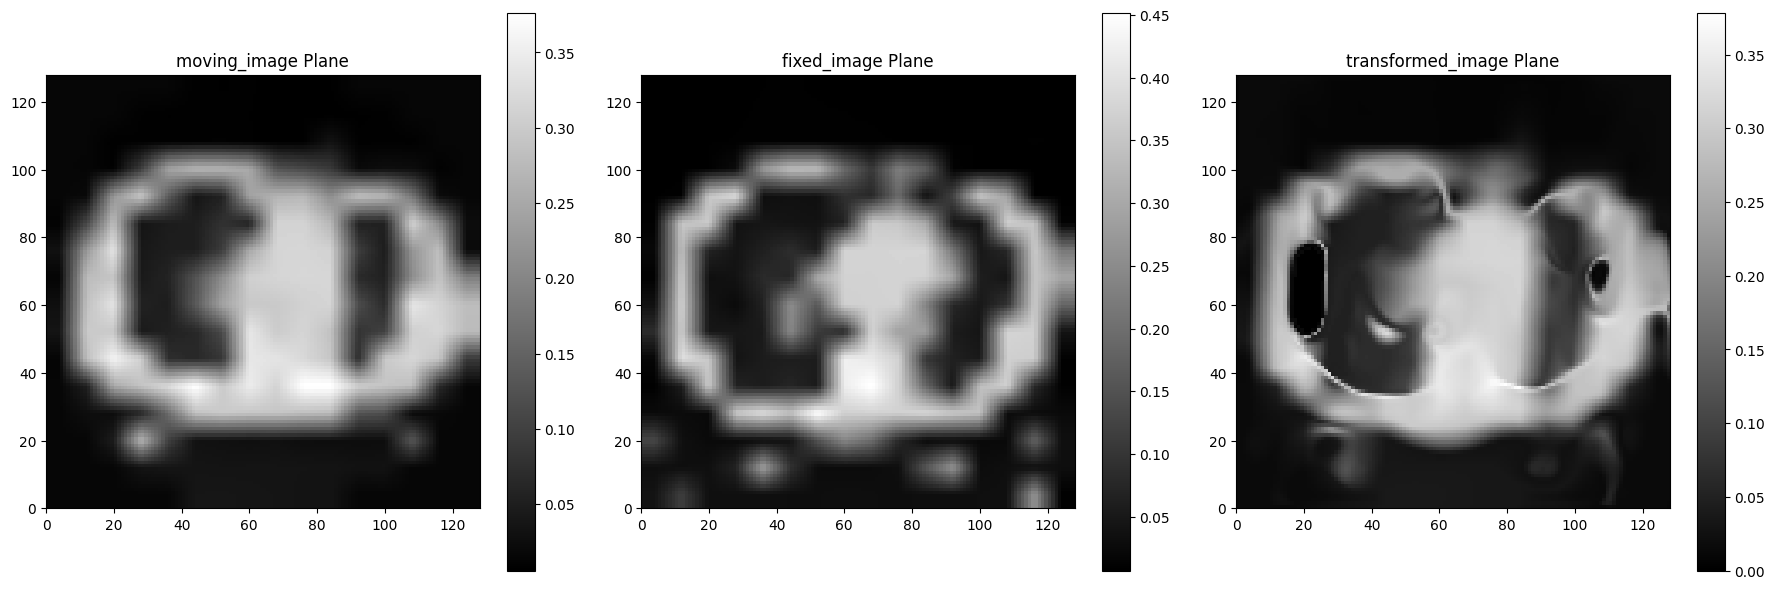

In [46]:
moving_image = source_16_128[0].cpu().numpy()
fixed_image = target_16_128[0].cpu().numpy()
transformed_image = moved_16_2[0].cpu().numpy()

import numpy as np
import torch
from tifffile import imsave
plt.figure(figsize=(18, 6))  # 図のサイズを大きくする


# moving_imageの表示32￥
plt.subplot(131)
A = moving_image[0, 64, :, :]
plt.imshow(A, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('moving_image Plane')
plt.colorbar()

# fixed_imageの表示
plt.subplot(132)
B = fixed_image[0, 64, :, :]
plt.imshow(B, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('fixed_image Plane')
plt.colorbar()
    
# transformed_imageの表示
plt.subplot(133)
C = transformed_image[0, 64, :, :]
plt.imshow(C, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('transformed_image Plane')
plt.colorbar()
    
plt.tight_layout()
plt.show()

In [47]:
imsave('source_16_128V2.tif', A)
imsave('target_16_128V2.tif', B)
imsave('moved_16_2V2.tif', C)

C:\Users\user\AppData\Local\Temp\ipykernel_8940\3459155433.py:1: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('source_16_128V2.tif', A)
C:\Users\user\AppData\Local\Temp\ipykernel_8940\3459155433.py:2: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('target_16_128V2.tif', B)
C:\Users\user\AppData\Local\Temp\ipykernel_8940\3459155433.py:3: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('moved_16_2V2.tif', C)


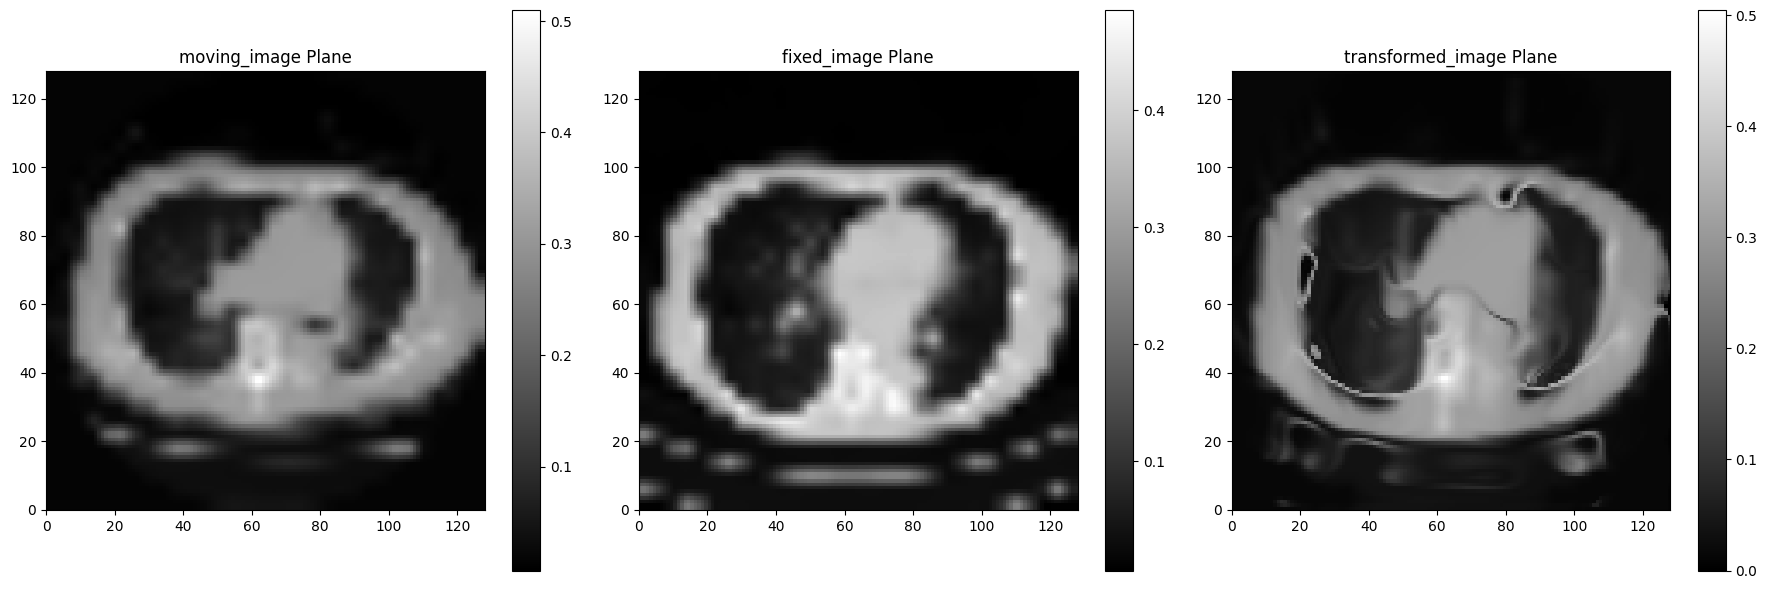

In [48]:
moving_image = source_32_128[0].cpu().numpy()
fixed_image = target_32_128[0].cpu().numpy()
transformed_image = moved_32_2[0].cpu().numpy()

import numpy as np
import torch
from tifffile import imsave
plt.figure(figsize=(18, 6))  # 図のサイズを大きくする


# moving_imageの表示32￥
plt.subplot(131)
A = moving_image[0, 64, :, :]
plt.imshow(A, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('moving_image Plane')
plt.colorbar()

# fixed_imageの表示
plt.subplot(132)
B = fixed_image[0, 64, :, :]
plt.imshow(B, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('fixed_image Plane')
plt.colorbar()
    
# transformed_imageの表示
plt.subplot(133)
C = transformed_image[0, 64, :, :]
plt.imshow(C, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('transformed_image Plane')
plt.colorbar()
    
plt.tight_layout()
plt.show()

In [49]:
imsave('source_32_128V2.tif', A)
imsave('target_32_128V2.tif', B)
imsave('moved_32_2V2.tif', C)

C:\Users\user\AppData\Local\Temp\ipykernel_8940\1429587951.py:1: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('source_32_128V2.tif', A)
C:\Users\user\AppData\Local\Temp\ipykernel_8940\1429587951.py:2: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('target_32_128V2.tif', B)
C:\Users\user\AppData\Local\Temp\ipykernel_8940\1429587951.py:3: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('moved_32_2V2.tif', C)


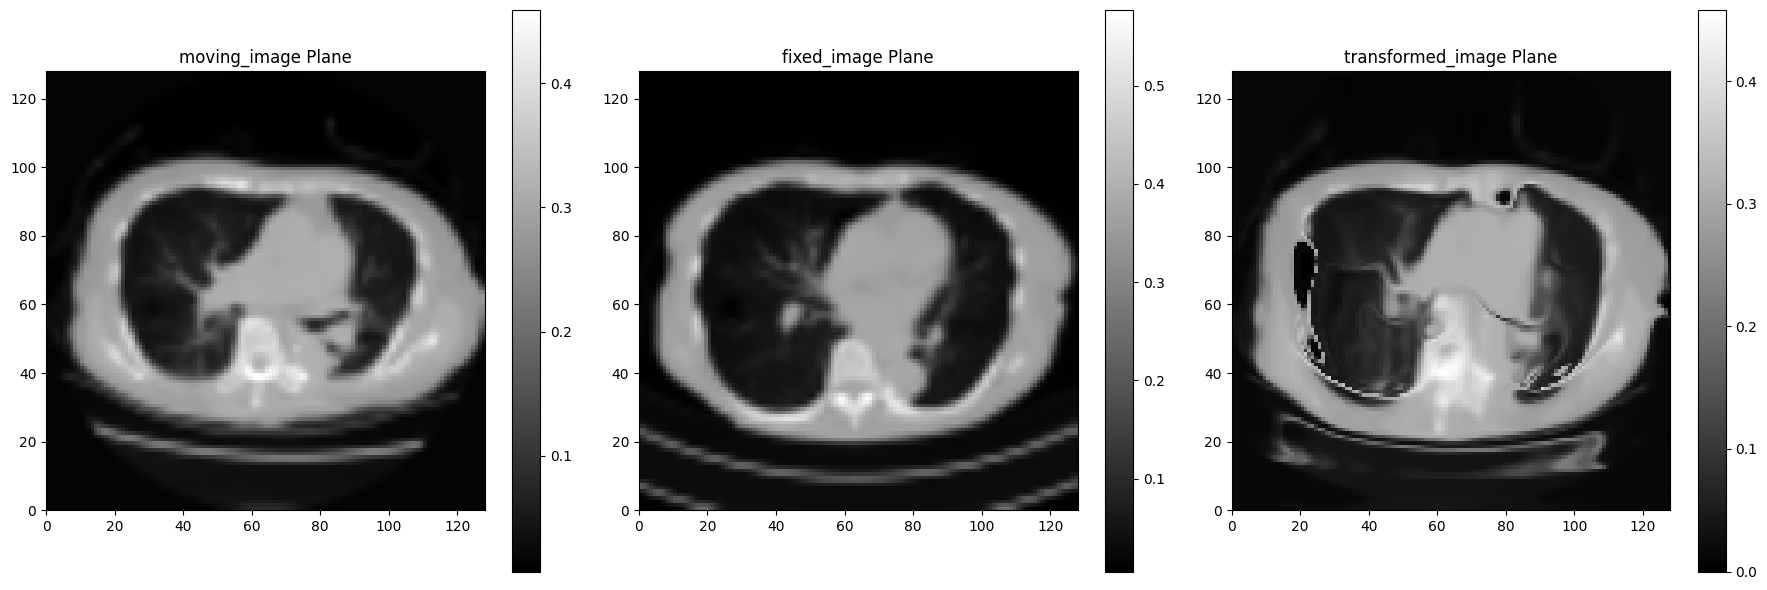

In [50]:
moving_image = source_64_128[0].cpu().numpy()
fixed_image = target_64_128[0].cpu().numpy()
transformed_image = moved_64_2[0].cpu().numpy()

import numpy as np
import torch
from tifffile import imsave
plt.figure(figsize=(18, 6))  # 図のサイズを大きくする


# moving_imageの表示32￥
plt.subplot(131)
A = moving_image[0, 64, :, :]
plt.imshow(A, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('moving_image Plane')
plt.colorbar()

# fixed_imageの表示
plt.subplot(132)
B = fixed_image[0, 64, :, :]
plt.imshow(B, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('fixed_image Plane')
plt.colorbar()
    
# transformed_imageの表示
plt.subplot(133)
C = transformed_image[0, 64, :, :]
plt.imshow(C, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('transformed_image Plane')
plt.colorbar()
    
plt.tight_layout()
plt.show()

In [51]:
imsave('source_64_128V2.tif', A)
imsave('target_64_128V2.tif', B)
imsave('moved_64_2V2.tif', C)

C:\Users\user\AppData\Local\Temp\ipykernel_8940\1868010170.py:1: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('source_64_128V2.tif', A)
C:\Users\user\AppData\Local\Temp\ipykernel_8940\1868010170.py:2: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('target_64_128V2.tif', B)
C:\Users\user\AppData\Local\Temp\ipykernel_8940\1868010170.py:3: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('moved_64_2V2.tif', C)


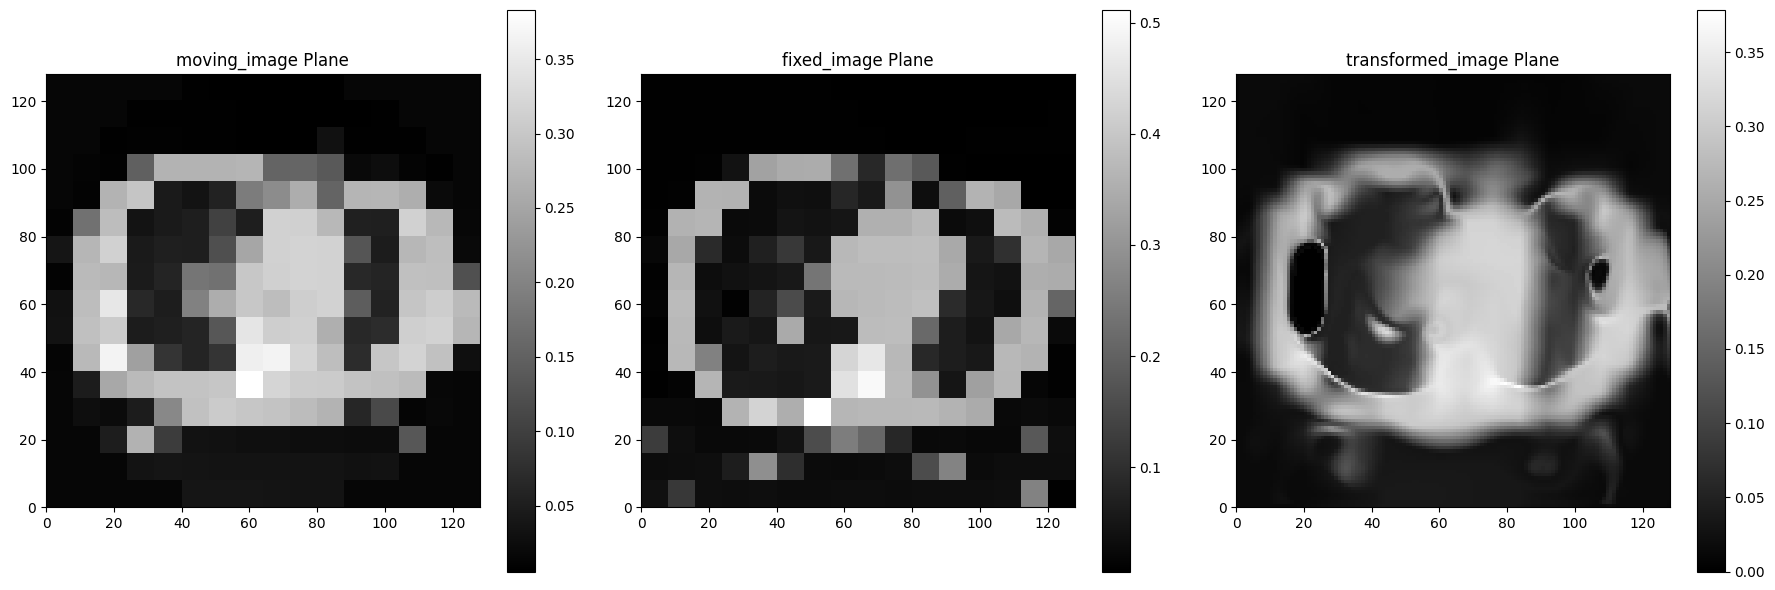

In [40]:
moving_image = source_16[0].cpu().numpy()
fixed_image = target_16[0].cpu().numpy()
transformed_image = moved_16_2[0].cpu().numpy()

import numpy as np
import torch
from tifffile import imsave
plt.figure(figsize=(18, 6))  # 図のサイズを大きくする


# moving_imageの表示32￥
plt.subplot(131)
A = moving_image[0, 8, :, :]
plt.imshow(A, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('moving_image Plane')
plt.colorbar()

# fixed_imageの表示
plt.subplot(132)
B = fixed_image[0, 8, :, :]
plt.imshow(B, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('fixed_image Plane')
plt.colorbar()
    
# transformed_imageの表示
plt.subplot(133)
C = transformed_image[0, 64, :, :]
plt.imshow(C, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('transformed_image Plane')
plt.colorbar()
    
plt.tight_layout()
plt.show()

In [41]:
imsave('AAA.tif', A)
imsave('BBB.tif', B)
imsave('CCC.tif', C)
# imsave('DDD.tif', D)
# imsave('EEE.tif', E)
# imsave('FFF.tif', F)
# imsave('GGG.tif', G)
# imsave('HHH.tif', H)
# imsave('III.tif', I)

C:\Users\user\AppData\Local\Temp\ipykernel_8940\1452923600.py:1: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('AAA.tif', A)
C:\Users\user\AppData\Local\Temp\ipykernel_8940\1452923600.py:2: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('BBB.tif', B)
C:\Users\user\AppData\Local\Temp\ipykernel_8940\1452923600.py:3: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('CCC.tif', C)
